# Transaction_stages analysis


- This project analyzes UPI transaction funnel stages from start to final transaction status.
- The goal is to identify where users or transactions fail, drop off, or face delays.
- Each transaction stage is studied to understand success, failure, latency, and error patterns.
- The analysis helps the company find specific stages that need improvement.
- By improving weak stages, the company can increase transaction success rates and provide a better user experience.

In [ ]:
import pandas as pd
from sqlalchemy import create_engine
import numpy as np
import os
import dotenv
import matplotlib.pyplot as plt
import seaborn as  sns
from scipy.stats import ttest_ind
from scipy.stats import stats
import warnings
warnings.filterwarnings("ignore")

dotenv.load_dotenv()

engine = create_engine(f"mysql+pymysql://{os.getenv('USER')}:{os.getenv('PASSWORD')}@{os.getenv('DB_HOST')}:{os.getenv('DB_PORT')}/{os.getenv('DB_NAME')}")

In [ ]:
# fetching all the data
df = pd.read_sql("select * from transaction_summary",engine)

In [20]:
# How our data look like.
df.sample(10)

,transaction_id,customer_id,timestamp,amount,transaction_type,payer_bank_id,payee_bank_id,device_id,final_stage_reached,os,...,stage_name,stage_status,error_code,error_description,error_category,payer_bank_name,payer_bank_tier,payee_bank_name,payee_bank_tier,stage_num
902336,TXN000134053,CUST0017856,2025-10-30 15:54:14,83.75,P2M,BNK012,BNK001,DEV0050436,STG7,Android,...,Enter Payee + Amount,PASSED,No Error,None,None,Yes Bank Ltd.,Tier-2,State Bank of India,Tier-1,2
861768,TXN000128027,CUST0038484,2025-10-26 14:40:25,57.63,P2P,BNK001,BNK002,DEV0046302,STG7,Android,...,Settlement Confirmed,PASSED,No Error,None,None,State Bank of India,Tier-1,HDFC Bank Ltd.,Tier-1,7
286373,TXN000042536,CUST0033408,2025-08-12 13:44:43,79.85,P2P,BNK007,BNK009,DEV0027482,STG7,Android,...,Enter Payee + Amount,PASSED,No Error,None,None,Kotak Mahindra Bank,Tier-2,Canara Bank,Tier-2,2
406519,TXN000060395,CUST0009194,2025-08-30 11:08:52,32.82,P2P,BNK003,BNK006,DEV0031295,STG7,Android,...,Enter Payee + Amount,PASSED,No Error,None,None,ICICI Bank Ltd.,Tier-1,Bank of Baroda,Tier-1,2
765092,TXN000113683,CUST0056380,2025-10-17 16:23:14,79.87,P2M,BNK001,BNK004,DEV0051179,STG7,Android,...,Enter Payee + Amount,PASSED,No Error,None,None,State Bank of India,Tier-1,Axis Bank Ltd.,Tier-1,2
86854,TXN000012902,CUST0013804,2025-07-13 22:40:14,165.05,P2P,BNK002,BNK002,DEV0049724,STG7,Android,...,App Open / Login,PASSED,No Error,None,None,HDFC Bank Ltd.,Tier-1,HDFC Bank Ltd.,Tier-1,1
226156,TXN000033600,CUST0019513,2025-08-03 07:46:34,109.51,P2P,BNK007,BNK002,DEV0057269,STG5,iOS,...,Issuing Bank Processing,FAILED,E203,Issuer bank ID not in correct format,TECHNICAL_DECLINE,Kotak Mahindra Bank,Tier-2,HDFC Bank Ltd.,Tier-1,5
958278,TXN000142369,CUST0069585,2025-11-04 16:47:21,225.42,P2P,BNK001,BNK012,DEV0048321,STG7,Android,...,Settlement Confirmed,PASSED,No Error,None,None,State Bank of India,Tier-1,Yes Bank Ltd.,Tier-2,7
387743,TXN000057612,CUST0007970,2025-08-28 18:49:49,1374.53,P2M,BNK001,BNK005,DEV0042215,STG7,Android,...,Enter Payee + Amount,PASSED,No Error,None,None,State Bank of India,Tier-1,Punjab National Bank,Tier-1,2
1230762,TXN000182822,CUST0005438,2025-12-13 19:22:15,227.93,P2M,BNK005,BNK021,DEV0047986,STG7,Android,...,Issuing Bank Processing,PASSED,No Error,None,None,Punjab National Bank,Tier-1,NPCI BHIM Services Ltd (NBSL),Tier-2,5


In [4]:
# Columns in the transaction_summary table.
df.columns

Index(['transaction_id', 'customer_id', 'timestamp', 'amount',
       'transaction_type', 'payer_bank_id', 'payee_bank_id', 'device_id',
       'final_stage_reached', 'os', 'network_type', 'stage_id', 'stage_name',
       'stage_status', 'error_code', 'error_description', 'error_category',
       'payer_bank_name', 'payer_bank_tier', 'payee_bank_name',
       'payee_bank_tier'],
      dtype='object')

## Transaction Stage Analysis

### Overall Funnel Performance

- Total transactions analyzed: **197,600**
- Transactions passed till **STG7**: **186,232**
- Transactions dropped before **STG7**: **11,368**

| Metric | Transaction Count | Percentage |
|---|---:|---:|
| Passed till STG7 | 186,232 | 94.25% |
| Dropped before STG7 | 11,368 | 5.75% |

### Transactions Stopped at Each Stage

| Stage | Stage Name | Transactions Stopped | % of Total Transactions |
|---|---|---:|---:|
| STG1 | App Open / Login | 843 | 0.43% |
| STG2 | Enter Payee + Amount | 1,187 | 0.60% |
| STG3 | UPI PIN Authentication | 3,554 | 1.80% |
| STG4 | PSP to NPCI Switch Routing | 1,770 | 0.90% |
| STG5 | Issuing Bank Processing | 2,473 | 1.25% |
| STG6 | Beneficiary Bank Credit | 1,541 | 0.78% |
| STG7 | Final Success Stage | 186,232 | 94.25% |

### Key Failure Insights

- The biggest failure spike is at **STG3 - UPI PIN Authentication**, where **3,554 transactions** stopped.
- STG3 alone contributes **31.26%** of all dropped transactions before STG7.
- The second major failure spike is at **STG5 - Issuing Bank Processing**, where **2,473 transactions** stopped.
- STG5 contributes **21.75%** of all dropped transactions before STG7.
- Together, **STG3 and STG5 account for 6,027 failed transactions**, which is **53.01%** of all transactions dropped before STG7.

### Business Interpretation

- Most transactions are successfully reaching STG7, with a pass rate of **94.25%**.
- However, the **5.75% drop-off before STG7** shows that there are still specific stages affecting transaction completion.
- The company should prioritize improvements in:
  - **STG3 - UPI PIN Authentication**, because it has the highest failure count.
  - **STG5 - Issuing Bank Processing**, because it has the second-highest failure count.
- Improving these two stages can significantly reduce transaction failures and improve the overall UPI transaction success rate.

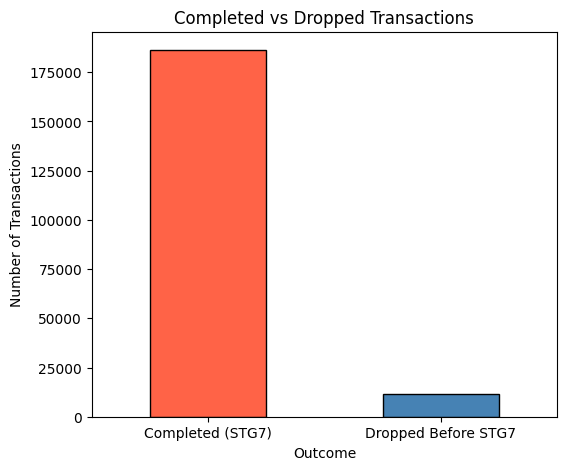

In [11]:
last_stage = (
    df
    .sort_values(["transaction_id","stage_num"])
    .groupby("transaction_id")
    .last()
)

last_stage["Outcome"] = last_stage["stage_id"].apply(
    lambda x: "Completed (STG7)" if x=="STG7" else "Dropped Before STG7"
)

outcome = last_stage["Outcome"].value_counts()

plt.figure(figsize=(6,5))

outcome.plot(
    kind="bar",
    color=["tomato","steelblue"],
    edgecolor="black"
)

plt.title("Completed vs Dropped Transactions")
plt.ylabel("Number of Transactions")

plt.xticks(rotation=0)

plt.show()

In [13]:
import pandas as pd
import matplotlib.pyplot as plt

# Order the stages correctly
stage_order = {
    "STG1": 1,
    "STG2": 2,
    "STG3": 3,
    "STG4": 4,
    "STG5": 5,
    "STG6": 6,
    "STG7": 7
}

df["stage_num"] = df["stage_id"].map(stage_order)

# Find the last stage reached for every transaction
last_stage = (
    df.sort_values(["transaction_id", "stage_num"])
    .groupby("transaction_id")
    .last()
    .reset_index()
)

# Count transactions by their last stage
stage_counts = (
    last_stage["stage_id"]
    .value_counts()
    .reindex(
        ["STG1","STG2","STG3","STG4","STG5","STG6","STG7"],
        fill_value=0
    )
)

stage_labels = {
    "STG1": "Login",
    "STG2": "Payee\nValidation",
    "STG3": "PIN\nAuthentication",
    "STG4": "NPCI\nRouting",
    "STG5": "Bank\nProcessing",
    "STG6": "Beneficiary\nCredit",
    "STG7": "Completed"
}

stage_counts.index = stage_counts.index.map(stage_labels)


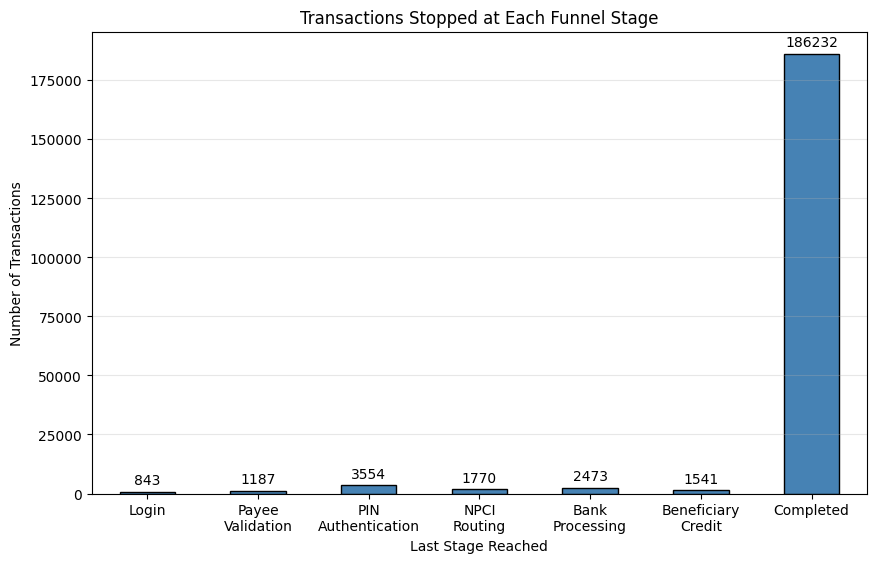

In [14]:
plt.figure(figsize=(10,6))

ax = stage_counts.plot(
    kind="bar",
    color="steelblue",
    edgecolor="black"
)

for container in ax.containers:
    ax.bar_label(container, padding=3)

plt.title("Transactions Stopped at Each Funnel Stage")
plt.xlabel("Last Stage Reached")
plt.ylabel("Number of Transactions")

plt.xticks(rotation=0)
plt.grid(axis="y", alpha=0.3)

plt.show()

## Error Category and UPI Failure Reason Analysis

### Failed Transactions by Error Category

Total failed transactions analyzed: **11,368**

| Error Category | Failed Transactions | % of Failed Transactions |
|---|---:|---:|
| BUSINESS_DECLINE | 5,456 | 47.99% |
| TECHNICAL_DECLINE | 4,173 | 36.71% |
| DEEMED_APPROVED | 1,511 | 13.29% |
| Unknown | 228 | 2.01% |

### Key Category Insights

- **BUSINESS_DECLINE** is the largest failure category with **5,456 failures**, contributing **47.99%** of all failed transactions.
- **TECHNICAL_DECLINE** is the second-largest category with **4,173 failures**, contributing **36.71%**.
- Together, **BUSINESS_DECLINE and TECHNICAL_DECLINE account for 9,629 failures**, which is **84.70%** of all failed transactions.
- **DEEMED_APPROVED** cases account for **1,511 failures**, or **13.29%**, showing cases where transaction confirmation or reversal handling needs improvement.
- **Unknown** errors account for **228 failures**, or **2.01%**, which indicates missing or incomplete error mapping.


### Major Failure Patterns

- The most frequent failure reason is **User cancelled transaction**, with **1,795 failures**, contributing **15.79%** of all failed transactions.
- The second-highest reason is **Incorrect UPI PIN entered**, with **1,697 failures**, contributing **14.93%**.
- These two user-side reasons together account for **3,492 failures**, or **30.72%** of all failed transactions.
- The largest technical issue is **Bank server timeout**, with **839 failures**, contributing **7.38%**.
- App and session-related failures are also significant, with **App crash / session expired** causing **818 failures**, or **7.20%**.
- Deemed-approved issues together account for **1,511 failures**, mainly due to:
  - **Reversal pending - bank unable to confirm:** 765 failures, 6.73%
  - **Debited but beneficiary credit not confirmed:** 746 failures, 6.56%

### Sectors of Improvement Required

| Improvement Sector | Related Failures | Failed Transactions | % of Failed Transactions | Recommended Action |
|---|---:|---:|---:|---|
| User Experience and Transaction Flow | User cancelled transaction | 1,795 | 15.79% | Reduce friction before payment confirmation, improve loading feedback, and make cancellation points easier to analyze. |
| PIN Authentication Experience | Incorrect UPI PIN entered | 1,697 | 14.93% | Improve PIN retry guidance, show clearer error messages, and reduce confusion during authentication. |
| Bank Infrastructure Reliability | Bank server timeout | 839 | 7.38% | Monitor bank response time, create timeout alerts, and identify banks with repeated timeout issues. |
| App Stability and Session Management | App crash / session expired | 818 | 7.20% | Improve app crash handling, session expiry warnings, and recovery flow after interruption. |
| Bank Data Validation | Issuer bank ID not in correct format | 780 | 6.86% | Strengthen validation rules before routing transactions and fix incorrect bank metadata. |
| Reversal and Confirmation Handling | Deemed-approved failures | 1,511 | 13.29% | Improve bank confirmation tracking, reversal status updates, and customer communication for pending cases. |
| Network Reliability | Network connection lost | 581 | 5.11% | Add better retry handling and transaction recovery for unstable network conditions. |
| Error Mapping and Data Quality | Unknown errors | 228 | 2.01% | Improve error-code mapping so every failed transaction has a clear failure category and reason. |

### Business Interpretation

- The company should first focus on **BUSINESS_DECLINE**, because it contributes the largest share of failures at **47.99%**.
- The highest priority user-side issues are **User cancelled transaction** and **Incorrect UPI PIN entered**, which together contribute **30.72%** of all failed transactions.
- Technical improvements should focus on **bank timeout**, **app crash/session expiry**, and **bank ID format validation**, which together contribute **21.44%** of all failed transactions.
- Improving user experience, authentication clarity, bank reliability, and reversal handling can directly reduce the majority of UPI transaction failures.

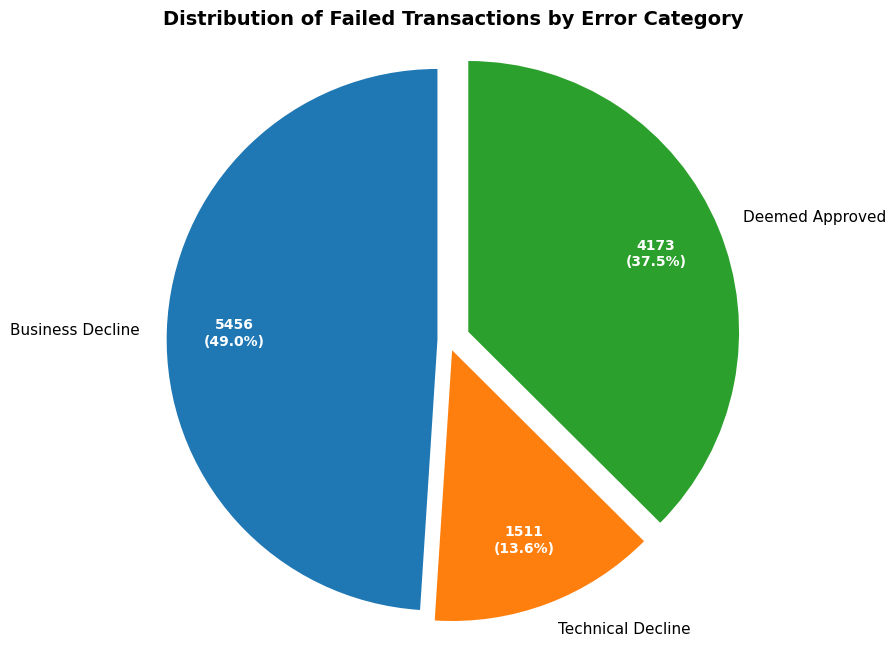

In [22]:
import matplotlib.pyplot as plt

# Count failures
error_category_counts = (
    df[df["error_category"].isin([
            "BUSINESS_DECLINE",
            "TECHNICAL_DECLINE",
            "DEEMED_APPROVED"
        ])
    ]
    .groupby("error_category")
    .size()
)

# Rename categories
error_category_counts.index = [
    "Business Decline",
    "Technical Decline",
    "Deemed Approved"
]

# Function to display count + percentage
def autopct_format(values):
    def my_format(pct):
        total = sum(values)
        count = int(round(pct * total / 100.0))
        return f"{count}\n({pct:.1f}%)"
    return my_format

plt.figure(figsize=(8,8))

wedges, texts, autotexts = plt.pie(
    error_category_counts,
    labels=error_category_counts.index,
    autopct=autopct_format(error_category_counts),
    startangle=90,
    explode=(0.04, 0.04, 0.08),
    pctdistance=0.75
)

plt.setp(texts, fontsize=11)
plt.setp(autotexts, fontsize=10, color="white", fontweight="bold")

plt.title(
    "Distribution of Failed Transactions by Error Category",
    fontsize=14,
    fontweight="bold"
)

plt.axis("equal")

plt.show()

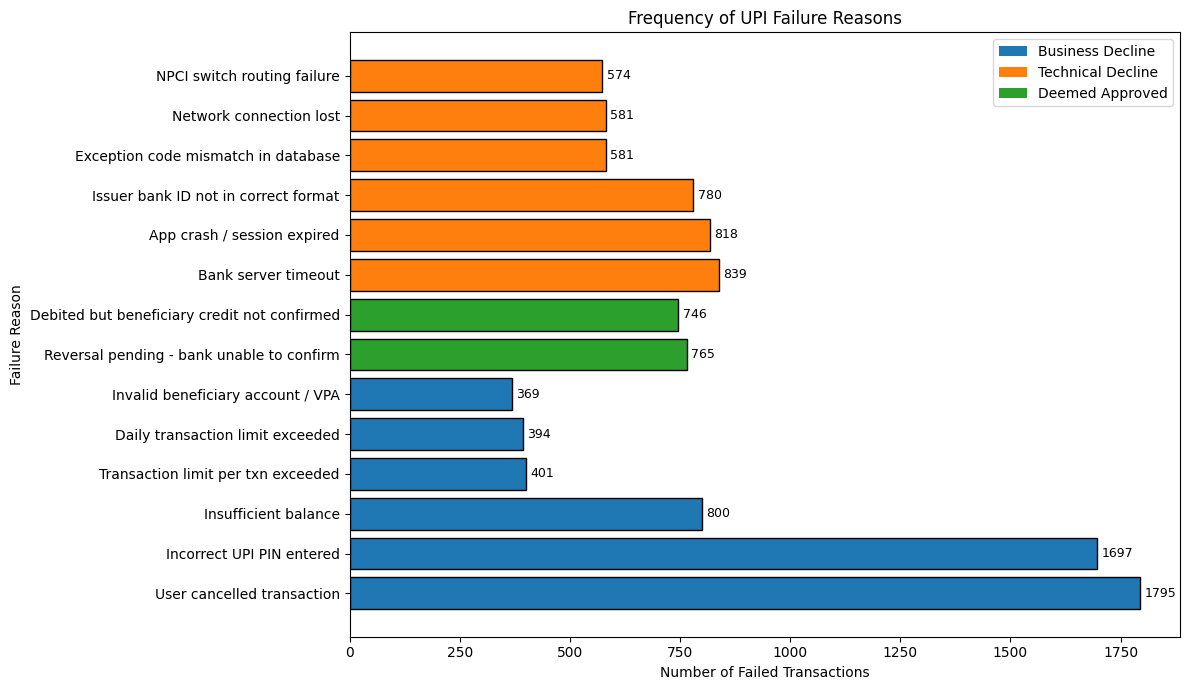

In [23]:
import pandas as pd
import matplotlib.pyplot as plt

# Remove successful transactions
errors = df[
    df["error_code"] != "No Error"
]

# Count frequency of each error description within each category
error_freq = (
    errors
    .groupby(["error_category", "error_description"])
    .size()
    .reset_index(name="count")
)

# Sort for better visualization
error_freq = error_freq.sort_values(
    ["error_category", "count"],
    ascending=[True, False]
)

plt.figure(figsize=(12,7))

colors = {
    "BUSINESS_DECLINE": "#1f77b4",
    "TECHNICAL_DECLINE": "#ff7f0e",
    "DEEMED_APPROVED": "#2ca02c"
}

bar_colors = error_freq["error_category"].map(colors)

ax = plt.barh(
    error_freq["error_description"],
    error_freq["count"],
    color=bar_colors,
    edgecolor="black"
)

# Add counts
for i, v in enumerate(error_freq["count"]):
    plt.text(v + 10, i, str(v), va="center", fontsize=9)

plt.xlabel("Number of Failed Transactions")
plt.ylabel("Failure Reason")
plt.title("Frequency of UPI Failure Reasons")

# Legend
from matplotlib.patches import Patch

legend_elements = [
    Patch(facecolor="#1f77b4", label="Business Decline"),
    Patch(facecolor="#ff7f0e", label="Technical Decline"),
    Patch(facecolor="#2ca02c", label="Deemed Approved")
]

plt.legend(handles=legend_elements)

plt.tight_layout()
plt.show()

## Bank Tier Failure Analysis

- **Tier-3 payer banks have the highest overall failure rate**: **13.83%**  
  - Total transactions: **21,071**
  - Failed transactions: **2,915**

- **Tier-2 payer banks show moderate failure rate**: **6.05%**  
  - Total transactions: **47,038**
  - Failed transactions: **2,847**

- **Tier-1 payer banks perform best** with the lowest failure rate: **4.33%**  
  - Total transactions: **129,491**
  - Failed transactions: **5,606**

### Top Payer Bank Failures at STG5

| Payer Bank | Tier | STG5 Transactions | STG5 Failures | STG5 Failure Rate |
|---|---|---:|---:|---:|
| Jammu & Kashmir Bank Ltd. | Tier-3 | 858 | 31 | 3.61% |
| DCB Bank Ltd. | Tier-3 | 1,248 | 43 | 3.45% |
| RBL Bank Ltd. | Tier-3 | 1,758 | 58 | 3.30% |
| Ujjivan Small Finance Bank | Tier-3 | 1,063 | 35 | 3.29% |
| Bandhan Bank Ltd. | Tier-3 | 1,723 | 56 | 3.25% |

### Key Takeaway

- The failure problem is concentrated more in **Tier-3 payer banks**.
- STG5 failures are also led by **Tier-3 banks**, showing that **bank processing reliability** needs improvement for this segment.
- Priority improvement area: **reduce STG5 bank processing failures for Tier-3 banks through better timeout handling, bank-side monitoring, and faster failure escalation.**

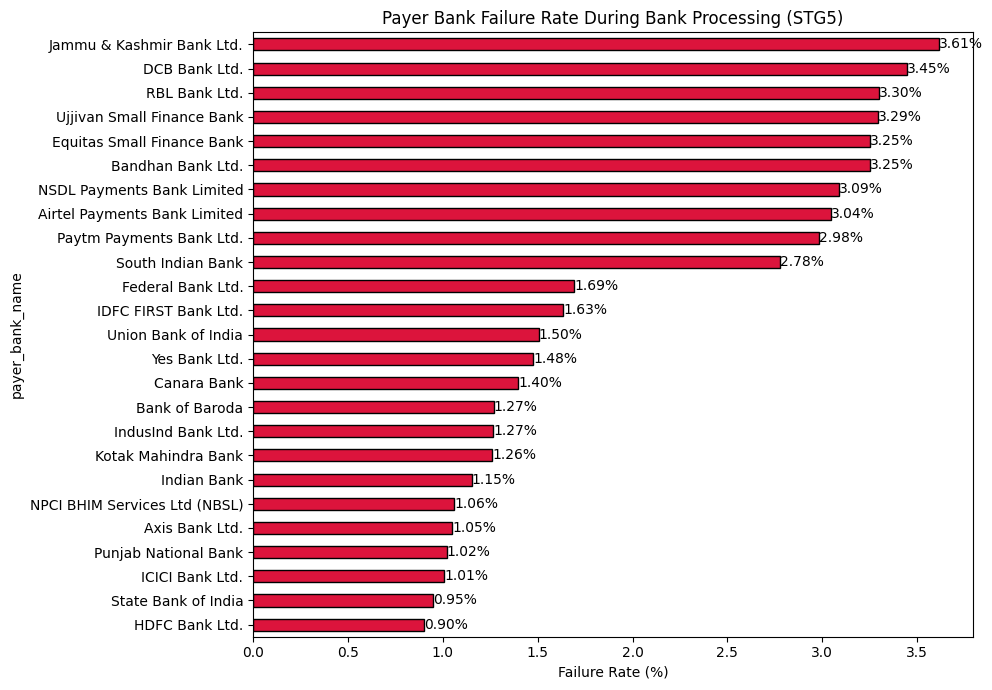

In [28]:
# All transactions that reached STG5
payer_total = (
    df[df["stage_id"] == "STG5"]
    .groupby("payer_bank_name")
    .size()
)

# Failed transactions at STG5
payer_failed = (
    df[
        (df["stage_id"] == "STG5") &
        (df["stage_status"] == "FAILED")
    ]
    .groupby("payer_bank_name")
    .size()
)

# Failure rate (%)
failure_rate = (
    payer_failed / payer_total * 100
).fillna(0).sort_values(ascending=True)

plt.figure(figsize=(10,7))

ax = failure_rate.plot(
    kind="barh",
    color="crimson",
    edgecolor="black"
)

for container in ax.containers:
    ax.bar_label(container, fmt="%.2f%%")

plt.title("Payer Bank Failure Rate During Bank Processing (STG5)")
plt.xlabel("Failure Rate (%)")

plt.tight_layout()
plt.show()

In [33]:
import pandas as pd
import matplotlib.pyplot as plt

# Transactions that reached STG5
stg5 = df[df["stage_id"] == "STG5"]

# Total transactions reaching STG5 by payer bank tier
total = (
    stg5
    .groupby("payer_bank_tier")["transaction_id"]
    .nunique()
)

# Failed transactions at STG5 by payer bank tier
failed = (
    stg5[stg5["stage_status"] == "FAILED"]
    .groupby("payer_bank_tier")["transaction_id"]
    .nunique()
)

# Calculate failure rate
tier_failure = pd.DataFrame({
    "Total Transactions": total,
    "Failed Transactions": failed
}).fillna(0)

tier_failure["Failure Rate (%)"] = (
    tier_failure["Failed Transactions"] /
    tier_failure["Total Transactions"] * 100
).round(2)

print(tier_failure)

                 Total Transactions  Failed Transactions  Failure Rate (%)
payer_bank_tier                                                           
Tier-1                       125877                 1250              0.99
Tier-2                        45221                  625              1.38
Tier-3                        19148                  598              3.12


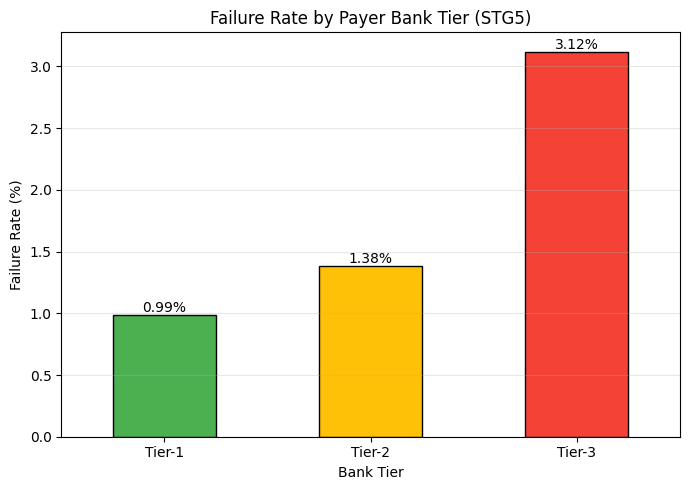

In [32]:
plt.figure(figsize=(7,5))

ax = tier_failure["Failure Rate (%)"].plot(
    kind="bar",
    color=["#4CAF50", "#FFC107", "#F44336"],
    edgecolor="black"
)

for container in ax.containers:
    ax.bar_label(container, fmt="%.2f%%")

plt.title("Failure Rate by Payer Bank Tier (STG5)")
plt.xlabel("Bank Tier")
plt.ylabel("Failure Rate (%)")

plt.xticks(rotation=0)
plt.grid(axis="y", alpha=0.3)

plt.tight_layout()
plt.show()

## Device OS Failure Analysis

- **Android** transactions: **154,283 total**, **8,882 failed** → **5.76% failure rate**
- **iOS** transactions: **43,317 total**, **2,486 failed** → **5.74% failure rate**
- The difference between Android and iOS failure rates is only **0.02 percentage points**, so **device OS does not show a major impact** on transaction failure.



In [35]:
import pandas as pd
import matplotlib.pyplot as plt

# Total unique transactions by OS
total_txns = (
    df
    .groupby("os")["transaction_id"]
    .nunique()
)

# Failed unique transactions by OS
failed_txns = (
    df[df["stage_status"] == "FAILED"]
    .groupby("os")["transaction_id"]
    .nunique()
)

# Create dataframe
os_failure = pd.DataFrame({
    "Total Transactions": total_txns,
    "Failed Transactions": failed_txns
}).fillna(0)

# Calculate failure rate
os_failure["Failure Rate (%)"] = (
    os_failure["Failed Transactions"] /
    os_failure["Total Transactions"] * 100
).round(2)

os_failure = os_failure.sort_values(
    "Failure Rate (%)",
    ascending=False
)

print(os_failure)

         Total Transactions  Failed Transactions  Failure Rate (%)
os                                                                
Android              154283                 8882              5.76
iOS                   43317                 2486              5.74


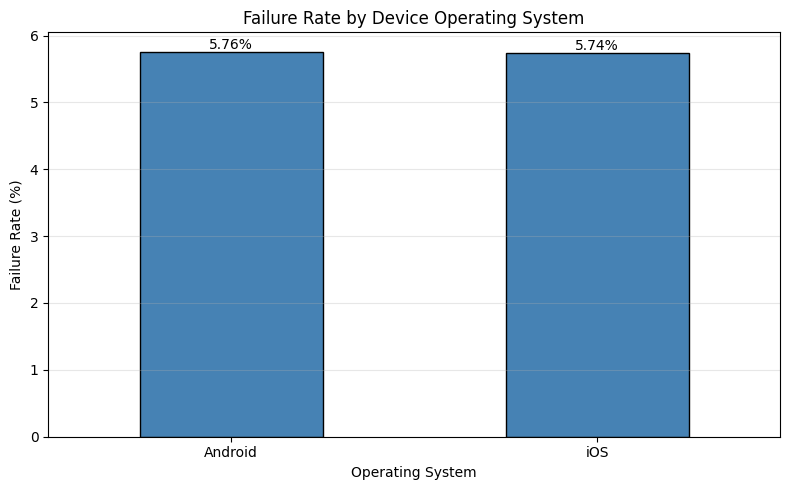

In [36]:
plt.figure(figsize=(8,5))

ax = os_failure["Failure Rate (%)"].plot(
    kind="bar",
    color="steelblue",
    edgecolor="black"
)

for container in ax.containers:
    ax.bar_label(container, fmt="%.2f%%")

plt.title("Failure Rate by Device Operating System")
plt.xlabel("Operating System")
plt.ylabel("Failure Rate (%)")

plt.xticks(rotation=0)

plt.grid(axis="y", alpha=0.3)

plt.tight_layout()

plt.show()

In [38]:
import pandas as pd
import matplotlib.pyplot as plt

# Total unique transactions for each OS
total_os = (
    df
    .groupby("os")["transaction_id"]
    .nunique()
)

# Failed transactions grouped by OS and error category
failed_os = (
    df[df["stage_status"] == "FAILED"]
    .groupby(["os", "error_category"])["transaction_id"]
    .nunique()
    .unstack(fill_value=0)
)

# Convert counts to percentages
failure_rate = (
    failed_os.div(total_os, axis=0) * 100
).round(2)

print(failure_rate)

error_category  BUSINESS_DECLINE  DEEMED_APPROVED  TECHNICAL_DECLINE
os                                                                  
Android                     2.73             0.77               2.15
iOS                         2.86             0.75               1.99


<Figure size 800x500 with 0 Axes>

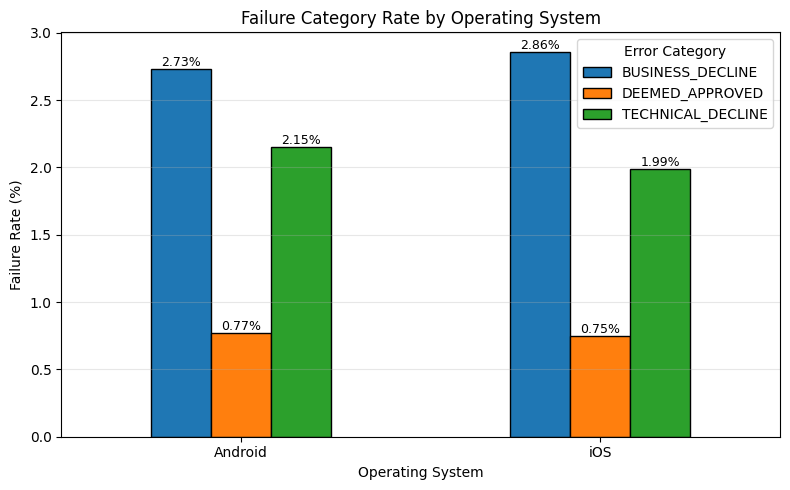

In [39]:
plt.figure(figsize=(8,5))

ax = failure_rate.plot(
    kind="bar",
    figsize=(8,5),
    edgecolor="black"
)

for container in ax.containers:
    ax.bar_label(container, fmt="%.2f%%", fontsize=9)

plt.title("Failure Category Rate by Operating System")
plt.xlabel("Operating System")
plt.ylabel("Failure Rate (%)")

plt.xticks(rotation=0)

plt.legend(title="Error Category")

plt.grid(axis="y", alpha=0.3)

plt.tight_layout()

plt.show()


## Transaction Type Failure Analysis

- **P2P** transactions: **88,785 total**, **5,158 failed** → **5.81% failure rate**
- **P2M** transactions: **108,815 total**, **6,210 failed** → **5.71% failure rate**
- The difference between P2P and P2M failure rates is only **0.10 percentage points**, so **transaction type does not strongly affect failures**, though both still contribute to overall failed transactions.

In [40]:
import pandas as pd
import matplotlib.pyplot as plt

# Total transactions
total_txns = (
    df
    .groupby("transaction_type")["transaction_id"]
    .nunique()
)

# Failed transactions
failed_txns = (
    df[df["stage_status"]=="FAILED"]
    .groupby("transaction_type")["transaction_id"]
    .nunique()
)

# Calculate failure rate
txn_failure = pd.DataFrame({
    "Total Transactions": total_txns,
    "Failed Transactions": failed_txns
}).fillna(0)

txn_failure["Failure Rate (%)"] = (
    txn_failure["Failed Transactions"] /
    txn_failure["Total Transactions"] * 100
).round(2)

print(txn_failure)

                  Total Transactions  Failed Transactions  Failure Rate (%)
transaction_type                                                           
P2M                           108815                 6210              5.71
P2P                            88785                 5158              5.81


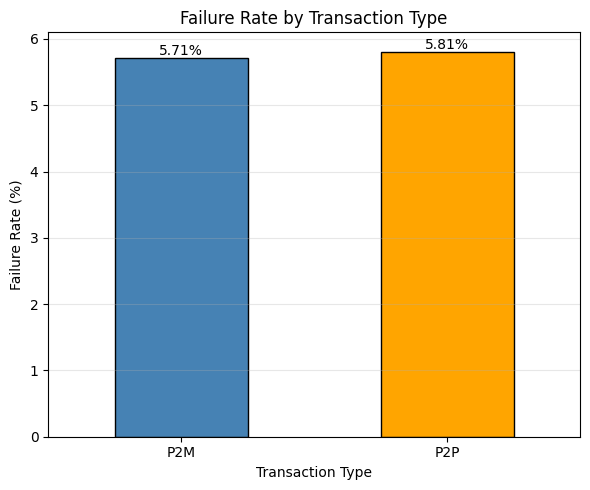

In [41]:
plt.figure(figsize=(6,5))

ax = txn_failure["Failure Rate (%)"].plot(
    kind="bar",
    color=["steelblue","orange"],
    edgecolor="black"
)

for container in ax.containers:
    ax.bar_label(container,fmt="%.2f%%")

plt.title("Failure Rate by Transaction Type")
plt.xlabel("Transaction Type")
plt.ylabel("Failure Rate (%)")

plt.xticks(rotation=0)

plt.grid(axis="y",alpha=0.3)

plt.tight_layout()

plt.show()

In [42]:
# Failed transactions only
failed = df[
    df["stage_status"]=="FAILED"
]

# Count failures
category = pd.crosstab(
    failed["transaction_type"],
    failed["error_category"],
    normalize="index"
) * 100

category = category.round(2)

print(category)

error_category    BUSINESS_DECLINE  DEEMED_APPROVED  TECHNICAL_DECLINE
transaction_type                                                      
P2M                          49.10            13.29              37.61
P2P                          48.83            13.89              37.28


<Figure size 800x500 with 0 Axes>

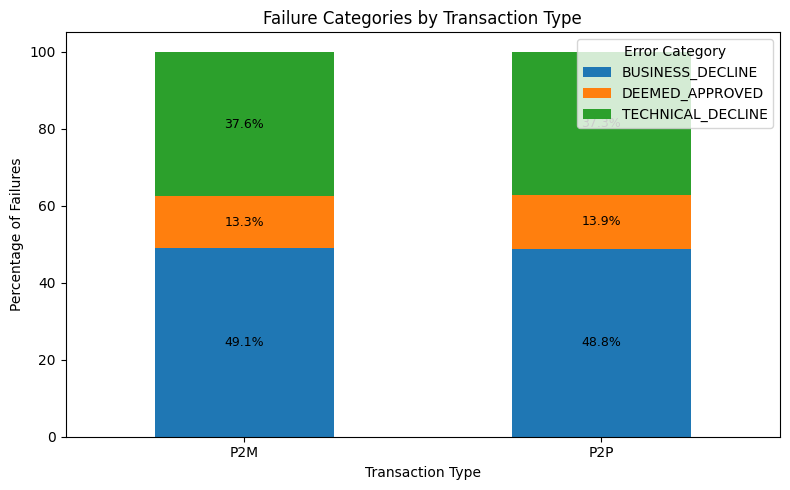

In [43]:
plt.figure(figsize=(8,5))

ax = category.plot(
    kind="bar",
    stacked=True,
    figsize=(8,5)
)

for container in ax.containers:
    ax.bar_label(container,
                 fmt="%.1f%%",
                 label_type="center",
                 fontsize=9)

plt.title("Failure Categories by Transaction Type")
plt.xlabel("Transaction Type")
plt.ylabel("Percentage of Failures")

plt.xticks(rotation=0)

plt.legend(title="Error Category")

plt.tight_layout()

plt.show()

In [44]:
stage = pd.crosstab(
    failed["transaction_type"],
    failed["stage_id"],
    normalize="index"
) * 100

stage = stage.round(2)

stage

stage_id,STG1,STG2,STG3,STG4,STG5,STG6
transaction_type,,,,,,
P2M,7.63,10.55,31.51,15.8,21.29,13.22
P2P,7.15,10.31,30.96,15.3,22.31,13.96


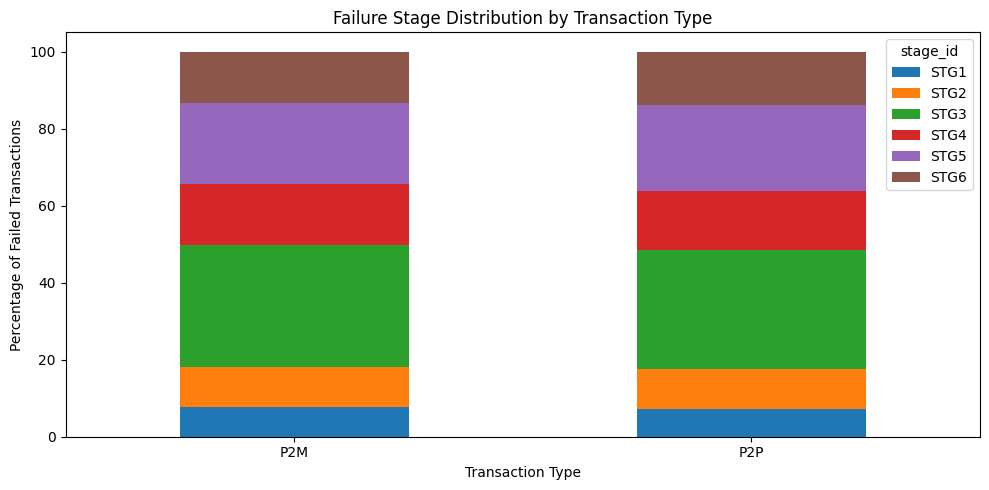

In [45]:
stage.plot(
    kind="bar",
    stacked=True,
    figsize=(10,5)
)

plt.title("Failure Stage Distribution by Transaction Type")

plt.ylabel("Percentage of Failed Transactions")

plt.xlabel("Transaction Type")

plt.xticks(rotation=0)

plt.tight_layout()

plt.show()